## K-Means for Data Labeling (Iris Dataset)

You are given an unlabeled dataset. Your goal is to assign labels to the data using the K-Means clustering algorithm.

The Iris dataset is known to contain three natural groups (species). Using K-Means, we set the number of clusters to K = 3 and allow the algorithm to group the data based on feature similarity.

Finally, we compare the cluster assignments produced by K-Means with the actual species labels to evaluate how well clustering can approximate true labels.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (12, 6)

In [77]:
# Make sure you have both files: data_iris_without_labels.csv and data_iris_with_actual_labels.csv

df = pd.read_csv("data_iris_without_labels.csv")
# df = pd.read_csv("data_iris_with_actual_labels.csv")

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


## EDA

Before clustering, understand the data:

- Check shape of data
- Look for missing values
- Understand feature scales
- Visualize pairwise relationships (optional)

### Why this matters:
K-Means is sensitive to scale and outliers.

In [78]:
# lets look at the columns data types

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None


In [79]:
# lets look at the common statistics

print(df.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


## More EDA can be done here, like plotting scatter plot between all pairs

In [80]:
X = df

In [81]:
# Scale the features for better clustering performance

scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

# X_scaled is now:
# Mean = 0
# Standard deviation = 1
# Ready for K-Means

In [82]:
# OPTIONAL: If you want to see the scaled features
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print(X_scaled_df.head())

   sepal_length  sepal_width  petal_length  petal_width
0     -0.900681     1.032057     -1.341272    -1.312977
1     -1.143017    -0.124958     -1.341272    -1.312977
2     -1.385353     0.337848     -1.398138    -1.312977
3     -1.506521     0.106445     -1.284407    -1.312977
4     -1.021849     1.263460     -1.341272    -1.312977


In [83]:
## OR you can look at unscaled/scaled feature side-by-side

print(X.loc[0].to_list(), "------>", X_scaled[0])
print(X.loc[1].to_list(), "------>", X_scaled[1])

[5.1, 3.5, 1.4, 0.2] ------> [-0.90068117  1.03205722 -1.3412724  -1.31297673]
[4.9, 3.0, 1.4, 0.2] ------> [-1.14301691 -0.1249576  -1.3412724  -1.31297673]


## Side note: 
**When feeding data to Kmeans, it is best to use numpy array, not dataframe, because k-means expects numeric matrix-like object**

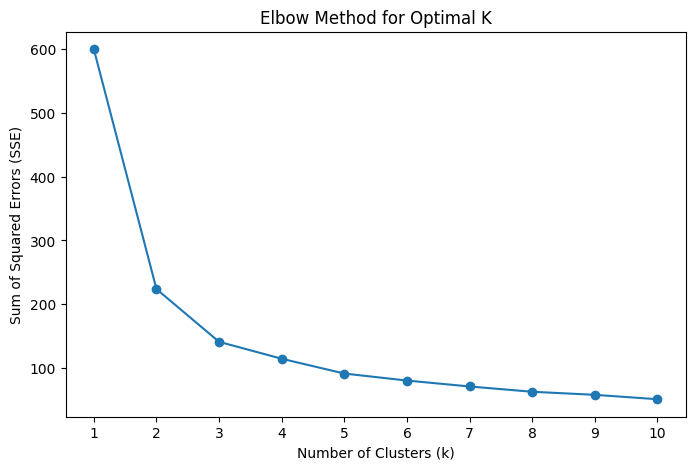

In [84]:
# Elbow method to determine the optimal K
# Side Note: Always use 
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,
}

# A list holds the SSE values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(1, 11))
plt.show()

In [85]:
# We see from above that K=3, is the optimal

# Apply KMeans clustering (K=3) with scaling
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the DataFrame
df["cluster"] = clusters

# Print cluster centers (scaled)
print("Cluster Centers (With Scaling - Standardized Features):")
print(kmeans.cluster_centers_)

Cluster Centers (With Scaling - Standardized Features):
[[-0.05021989 -0.88029181  0.34753171  0.28206327]
 [-1.01457897  0.84230679 -1.30487835 -1.25512862]
 [ 1.13597027  0.09659843  0.996271    1.01717187]]


In [86]:
# lets print the cluster labels of the few points
print(kmeans.labels_[:10])

[1 1 1 1 1 1 1 1 1 1]


In [87]:
print(df)

     sepal_length  sepal_width  petal_length  petal_width  cluster
0             5.1          3.5           1.4          0.2        1
1             4.9          3.0           1.4          0.2        1
2             4.7          3.2           1.3          0.2        1
3             4.6          3.1           1.5          0.2        1
4             5.0          3.6           1.4          0.2        1
..            ...          ...           ...          ...      ...
145           6.7          3.0           5.2          2.3        2
146           6.3          2.5           5.0          1.9        0
147           6.5          3.0           5.2          2.0        2
148           6.2          3.4           5.4          2.3        2
149           5.9          3.0           5.1          1.8        0

[150 rows x 5 columns]


In [88]:
# Lets see how many clusters and their corresponding counts
import numpy as np
unique, counts = np.unique(kmeans.labels_, return_counts=True)

print(unique)
print(counts)

[0 1 2]
[53 50 47]


In [89]:
# Lets zip above and put them in dictionary: key=cluster-label : value=count on how many belong to each clusters
dict_data = dict(zip(unique, counts))
print(dict_data)

{0: 53, 1: 50, 2: 47}


# Now lets compare with actual labels

In [90]:
# 1)
df_actual = pd.read_csv("data_iris_with_actual_labels.csv")
print(df_actual.sample(10))

     sepal_length  sepal_width  petal_length  petal_width     species
50            7.0          3.2           4.7          1.4  versicolor
7             5.0          3.4           1.5          0.2      setosa
79            5.7          2.6           3.5          1.0  versicolor
81            5.5          2.4           3.7          1.0  versicolor
115           6.4          3.2           5.3          2.3   virginica
117           7.7          3.8           6.7          2.2   virginica
141           6.9          3.1           5.1          2.3   virginica
19            5.1          3.8           1.5          0.3      setosa
14            5.8          4.0           1.2          0.2      setosa
131           7.9          3.8           6.4          2.0   virginica


In [91]:
#2)  actual labels
y_actual = df_actual['species']

In [92]:
# 3) Lets Create a Cluster vs Species Crosstab (Most Important Step)
print(pd.crosstab(df['cluster'], y_actual))

# Observation:
# Cluster 0 -> mix of versicolor & virginica. Mainly versicolor
# Cluster 1 -> pure setosa
# Cluster 2 -> mix of versicolor & virginica. Mainly virginica
# Labels are arbitrary numbers

species  setosa  versicolor  virginica
cluster                               
0             0          39         14
1            50           0          0
2             0          11         36


In [ ]:
# KMeans assigns cluster labels arbitrarily. That means Cluster 0 doesn’t necessarily
# correspond to Class 0 — but that’s totally fine.

# You don't fix KMeans labels directly, but you relabel the clusters to best match 
# the actual classes using a mapping based on the majority vote within each cluster.


In [93]:
# 4) manual mapping based on above step
cluster_to_species = {
    0: 'versicolor',
    1: 'setosa',
    2: 'virginica'
}

df['cluster_mapped'] = df['cluster'].map(cluster_to_species)
df['actual_species'] = y_actual
print(df.sample(10))

     sepal_length  sepal_width  petal_length  petal_width  cluster  \
68            6.2          2.2           4.5          1.5        0   
22            4.6          3.6           1.0          0.2        1   
119           6.0          2.2           5.0          1.5        0   
82            5.8          2.7           3.9          1.2        0   
50            7.0          3.2           4.7          1.4        2   
20            5.4          3.4           1.7          0.2        1   
123           6.3          2.7           4.9          1.8        0   
118           7.7          2.6           6.9          2.3        2   
49            5.0          3.3           1.4          0.2        1   
91            6.1          3.0           4.6          1.4        0   

    cluster_mapped actual_species  
68      versicolor     versicolor  
22          setosa         setosa  
119     versicolor      virginica  
82      versicolor     versicolor  
50       virginica     versicolor  
20          s

In [94]:
# OPTIONAL: Save it to excel to compare output
df.to_excel("DELETEout.xlsx")

In [96]:
# Now compare
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(df['actual_species'], df['cluster_mapped'])
print("Accuracy after mapping:", accuracy)

# NOTE: Accuracy is not directly available in unsupervised learning — we create it only because we know true labels.

Accuracy after mapping: 0.8333333333333334


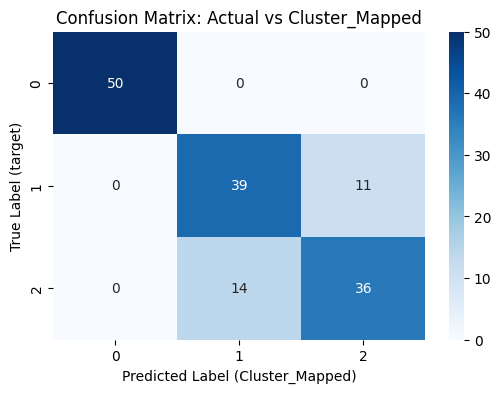

In [98]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(df['actual_species'], df['cluster_mapped'])

# Plot it
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])

plt.xlabel('Predicted Label (Cluster_Mapped)')
plt.ylabel('True Label (target)')
plt.title('Confusion Matrix: Actual vs Cluster_Mapped')
plt.show()

In [101]:
# Adjusted Rand Index: These metrics work directly with clusters and true labels:
# (No Label Mapping Required)
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(df['actual_species'], df['cluster'])
print(ari)

# ARI=1.0 → perfect clustering
# ARI=0.0 → random
# ARI = 0.62 means clustering is significantly better than random and captures most of the true structure in the data.

0.6201351808870379

# STOP

In [ ]:
# Now lets measure the performance of our kmeans clustersing
# 1) silhouette_score:
# - Measures how well each point lies within its cluster
# - Considers cohesion (how close points in a cluster are) and separation (how far clusters are from each other)

# Range: -1 to 1
# 1 = well-clustered
# 0 = overlapping clusters
# <0 = bad clustering



from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {score:.3f}")


In [107]:
# 2. Inertia (Within-Cluster Sum of Squares)
# - Comes directly from KMeans
# - Measures how tight the clusters are
# - Lower is better, but it always decreases with more clusters — so not a great standalone metric

print(f"Inertia (WCSS): {kmeans.inertia_}")


Inertia (WCSS): 140.96581663074699


# PCA

In [100]:
df.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,cluster,cluster_mapped,actual_species
71,6.1,2.8,4.0,1.3,0,versicolor,versicolor
1,4.9,3.0,1.4,0.2,1,setosa,setosa
80,5.5,2.4,3.8,1.1,0,versicolor,versicolor
115,6.4,3.2,5.3,2.3,2,virginica,virginica
44,5.1,3.8,1.9,0.4,1,setosa,setosa
8,4.4,2.9,1.4,0.2,1,setosa,setosa
70,5.9,3.2,4.8,1.8,2,virginica,versicolor
35,5.0,3.2,1.2,0.2,1,setosa,setosa
6,4.6,3.4,1.4,0.3,1,setosa,setosa
24,4.8,3.4,1.9,0.2,1,setosa,setosa


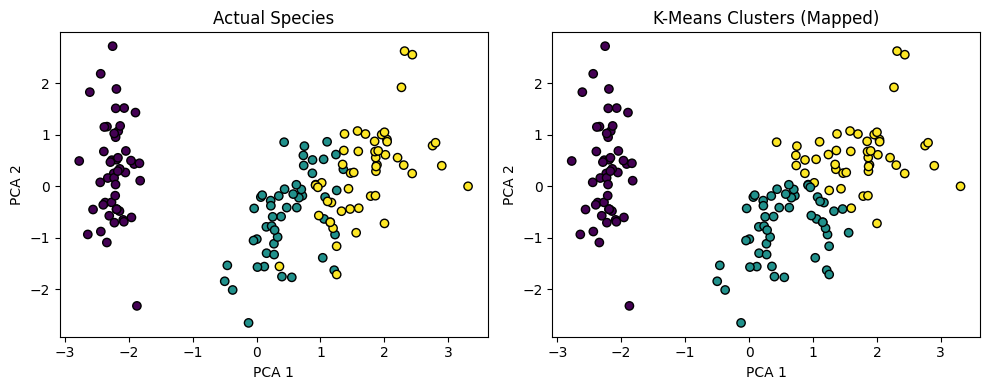

In [104]:

# 1) Select only numeric feature columns
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]


# 2) Scale before PCA (VERY IMPORTANT)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)


# 3) Apply PCA (2 components)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


# 4) Encode labels for coloring
from sklearn.preprocessing import LabelEncoder

le_actual = LabelEncoder()
actual_encoded = le_actual.fit_transform(df['actual_species'])

le_cluster = LabelEncoder()
cluster_encoded = le_cluster.fit_transform(df['cluster_mapped'])


# 5) Plot Side-by-Side PCA Scatter Plots
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# Actual Classes
plt.subplot(1, 2, 1)
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=actual_encoded,
    cmap='viridis',
    edgecolor='k'
)
plt.title("Actual Species")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# KMeans Clusters (Mapped)
plt.subplot(1, 2, 2)
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=cluster_encoded,
    cmap='viridis',
    edgecolor='k'
)
plt.title("K-Means Clusters (Mapped)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()

## observation:
# The actual clusters almost match kmeans clusters. 

Silhouette Score: 0.459


Inertia (WCSS): 140.96581663074699
